# PFA — Pipeline mensuel S&P 500 + NASA GISS

1. **Fusion données** (section 1) — identique à `scripts/build_monthly_dataset.py`.  
2. **Résultat principal** (section 2) — pipeline **v2** : baseline marché renforcée + climat lissé + `GradientBoosting` ; aligné sur `scripts/train_primary_result.py`.

Protocole détaillé : [PROTOCOL.md](PROTOCOL.md). Ancienne comparaison LR/RF minimale : `scripts/train_baseline_climate.py`.

**Important :** répertoire de travail = dossier `MLStudy2`.

In [8]:
from pathlib import Path

import pandas as pd

BASE = Path.cwd()
SP500_PATH = BASE / "dataSets" / "sp500_monthly_returns.csv"
TEMP_PATH = BASE / "dataSets" / "gistemp250_GHCNv4.csv"
OUT_PATH = BASE / "data" / "monthly_merged.csv"
CHUNKSIZE = 1_000_000

assert SP500_PATH.exists(), f"Missing {SP500_PATH} — cd into MLStudy2 first"
assert TEMP_PATH.exists(), f"Missing {TEMP_PATH}"

## 1. Agrégation climat (chunks) + fusion S&P

Le CSV GISS est volumineux : lecture par morceaux, moyennes mensuelles globale / nord / sud.

In [9]:
def monthly_temp_aggregates_chunked(csv_path: Path, chunksize: int = CHUNKSIZE) -> pd.DataFrame:
    g_parts: list[pd.DataFrame] = []
    n_parts: list[pd.DataFrame] = []
    s_parts: list[pd.DataFrame] = []

    for chunk in pd.read_csv(csv_path, chunksize=chunksize):
        chunk = chunk.dropna(subset=["tempanomaly_degC", "time"])
        if chunk.empty:
            continue
        g_parts.append(
            chunk.groupby("time", sort=False)["tempanomaly_degC"].agg(["sum", "count"])
        )
        north = chunk.loc[chunk["lat"] > 0]
        if not north.empty:
            n_parts.append(
                north.groupby("time", sort=False)["tempanomaly_degC"].agg(["sum", "count"])
            )
        south = chunk.loc[chunk["lat"] < 0]
        if not south.empty:
            s_parts.append(
                south.groupby("time", sort=False)["tempanomaly_degC"].agg(["sum", "count"])
            )

    def combine(parts: list[pd.DataFrame]) -> pd.Series:
        if not parts:
            return pd.Series(dtype=float)
        agg = pd.concat(parts).groupby(level=0).sum()
        return agg["sum"] / agg["count"]

    temp_global = combine(g_parts).rename("temp_global_mean")
    temp_north = combine(n_parts).rename("temp_north_mean")
    temp_south = combine(s_parts).rename("temp_south_mean")

    temp_df = temp_global.reset_index()
    temp_df = temp_df.merge(temp_north.reset_index(), on="time", how="left")
    temp_df = temp_df.merge(temp_south.reset_index(), on="time", how="left")
    temp_df = temp_df.rename(columns={"time": "Date"})
    temp_df["Date"] = pd.to_datetime(
        temp_df["Date"].astype(str).str.strip() + "-01", errors="coerce"
    )
    return temp_df.dropna(subset=["Date"])

In [10]:
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)

temp_df = monthly_temp_aggregates_chunked(TEMP_PATH)

sp500 = pd.read_csv(SP500_PATH, skiprows=[1])
sp500["Date"] = pd.to_datetime(
    sp500["Date"].astype(str).str.strip() + "-01", errors="coerce"
)
sp500 = sp500[["Date", "Close", "Monthly_Return"]].copy()
sp500["Target"] = (sp500["Monthly_Return"] > 0).astype(int)

df_merged = sp500.merge(temp_df, on="Date", how="inner")
df_merged = df_merged.sort_values("Date").reset_index(drop=True)
before = len(df_merged)
df_merged = df_merged.drop_duplicates(subset=["Date"], keep="first").reset_index(drop=True)
if len(df_merged) < before:
    print(f"Dropped {before - len(df_merged)} duplicate month row(s).")

df_merged = df_merged[
    [
        "Date",
        "Close",
        "Monthly_Return",
        "Target",
        "temp_global_mean",
        "temp_north_mean",
        "temp_south_mean",
    ]
]

df_merged.to_csv(OUT_PATH, index=False)
print("Wrote:", OUT_PATH)
print("Shape:", df_merged.shape)
print("Date range:", df_merged["Date"].min(), "→", df_merged["Date"].max())
df_merged.head()

Wrote: /Users/the.akoum/Library/Mobile Documents/com~apple~CloudDocs/Mac/EPITA/sem10/PFA/MLStudy2/data/monthly_merged.csv
Shape: (1178, 7)
Date range: 1928-01-01 00:00:00 → 2026-02-01 00:00:00


,Date,Close,Monthly_Return,Target,temp_global_mean,temp_north_mean,temp_south_mean
0,1928-01-01,17.570000,-0.005096,0,0.427801,0.614756,-0.282874
1,1928-02-01,17.260000,-0.017644,0,0.458299,0.614908,-0.143222
2,1928-03-01,19.280001,0.117034,1,-0.524084,-0.648123,-0.044435
3,1928-04-01,19.750000,0.024378,1,-0.479106,-0.681306,0.302013
4,1928-05-01,20.000000,0.012658,1,-0.289956,-0.222148,-0.547109


### Visualisations — chaque jeu en fonction du temps

- **`dataSets/sp500_monthly_returns.csv`** : clôture et rendement mensuel.  
- **`dataSets/gistemp250_GHCNv4.csv`** : on trace les **moyennes mensuelles agrégées** (globale, hémisphère nord, hémisphère sud) — le CSV brut est trop volumineux pour un tracé ligne à ligne.  
- **`data/monthly_merged.csv`** : période **commune** après fusion (S&P + température globale, double échelle).

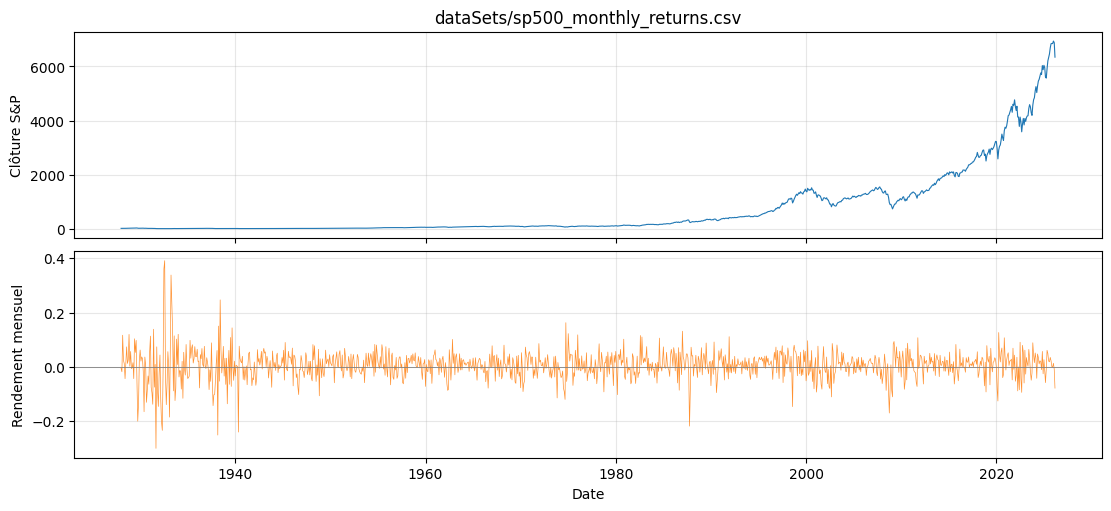

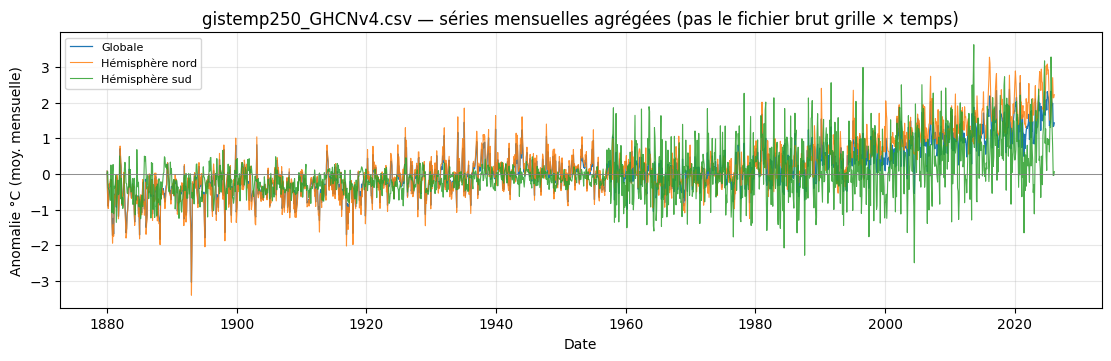

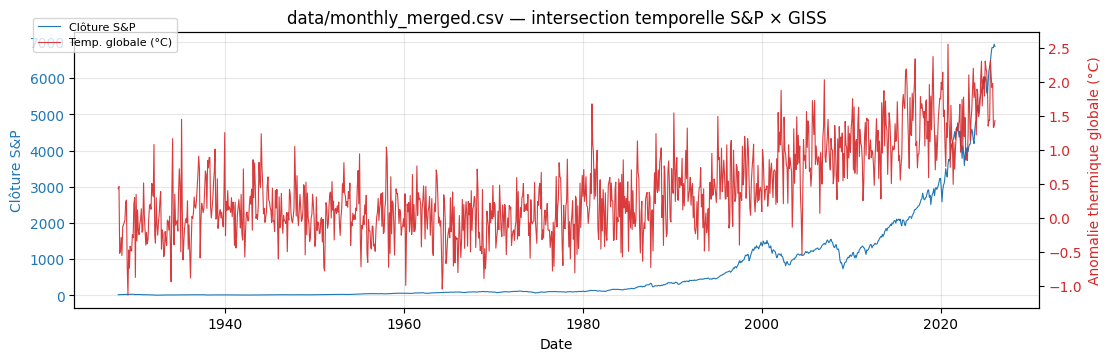

In [11]:
import matplotlib.pyplot as plt

# --- 1) CSV S&P seul ---
sp_raw = pd.read_csv(SP500_PATH, skiprows=[1])
sp_raw["Date"] = pd.to_datetime(
    sp_raw["Date"].astype(str).str.strip() + "-01", errors="coerce"
)
sp_raw = sp_raw.dropna(subset=["Date"]).sort_values("Date")

fig1, axes1 = plt.subplots(2, 1, sharex=True, figsize=(11, 5), layout="constrained")
axes1[0].plot(sp_raw["Date"], sp_raw["Close"], color="#1f77b4", lw=0.8)
axes1[0].set_ylabel("Clôture S&P")
axes1[0].set_title("dataSets/sp500_monthly_returns.csv")
axes1[0].grid(True, alpha=0.3)
axes1[1].plot(sp_raw["Date"], sp_raw["Monthly_Return"], color="#ff7f0e", lw=0.5, alpha=0.85)
axes1[1].axhline(0, color="gray", lw=0.6)
axes1[1].set_ylabel("Rendement mensuel")
axes1[1].set_xlabel("Date")
axes1[1].grid(True, alpha=0.3)
plt.show()

# --- 2) Agrégat mensuel GISS (même calcul que la fusion) ---
try:
    tdf = temp_df.copy()
except NameError:
    tdf = monthly_temp_aggregates_chunked(TEMP_PATH)

fig2, ax2 = plt.subplots(figsize=(11, 3.5), layout="constrained")
ax2.plot(tdf["Date"], tdf["temp_global_mean"], label="Globale", lw=0.9)
ax2.plot(tdf["Date"], tdf["temp_north_mean"], label="Hémisphère nord", lw=0.8, alpha=0.85)
ax2.plot(tdf["Date"], tdf["temp_south_mean"], label="Hémisphère sud", lw=0.8, alpha=0.85)
ax2.axhline(0, color="gray", lw=0.6)
ax2.set_ylabel("Anomalie °C (moy. mensuelle)")
ax2.set_xlabel("Date")
ax2.set_title(
    "gistemp250_GHCNv4.csv — séries mensuelles agrégées (pas le fichier brut grille × temps)"
)
ax2.legend(loc="upper left", fontsize=8)
ax2.grid(True, alpha=0.3)
plt.show()

# --- 3) Jeu fusionné (fichier écrit : data/monthly_merged.csv) ---
try:
    m = df_merged.sort_values("Date").copy()
except NameError:
    m = pd.read_csv(OUT_PATH, parse_dates=["Date"]).sort_values("Date")

fig3, ax_l = plt.subplots(figsize=(11, 3.5), layout="constrained")
ax_r = ax_l.twinx()
ax_l.plot(m["Date"], m["Close"], color="#1f77b4", lw=0.8, label="Clôture S&P")
ax_r.plot(m["Date"], m["temp_global_mean"], color="#d62728", lw=0.8, alpha=0.9, label="Temp. globale (°C)")
ax_l.set_xlabel("Date")
ax_l.set_ylabel("Clôture S&P", color="#1f77b4")
ax_r.set_ylabel("Anomalie thermique globale (°C)", color="#d62728")
ax_l.tick_params(axis="y", labelcolor="#1f77b4")
ax_r.tick_params(axis="y", labelcolor="#d62728")
ax_l.set_title("data/monthly_merged.csv — intersection temporelle S&P × GISS")
ax_l.grid(True, alpha=0.3)
fig3.legend(
    handles=[*ax_l.get_lines(), *ax_r.get_lines()],
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),
    fontsize=8,
)
plt.show()

In [12]:
df_merged.tail()

,Date,Close,Monthly_Return,Target,temp_global_mean,temp_north_mean,temp_south_mean
1173,2025-10-01,6840.200195,0.022687,1,1.915236,2.298013,1.254475
1174,2025-11-01,6849.089844,0.001300,1,1.975817,2.696403,0.738011
1175,2025-12-01,6845.500000,-0.000524,0,1.325928,2.130964,-0.046703
1176,2026-01-01,6939.029785,0.013663,1,1.346732,2.136434,-0.043802
1177,2026-02-01,6878.879883,-0.008668,0,1.428152,2.218732,0.061494


## 2. Résultat principal (v2) — GradientBoosting

**Changement par rapport à la v1 :** baseline **marché** plus sérieuse (lags 1–6 + volatilité 3/6 mois) ; climat lissé (**moyenne mobile 12 mois** sur l’anomalie + lags) ; classifieur **GradientBoosting** (souvent meilleur sur ce type de tableau).

**Cible :** même règle SMART — signe du rendement du **mois courant** ; les features n’utilisent que le **passé**.

**À dire au jury :** le modèle enrichi bat le **baseline marché** sur le test chronologique (≈ +2 pp accuracy sur notre split). La précision reste **sous** le classifieur « toujours up » (~65 % sur la fenêtre test) : le marché mensuel est difficile ; l’intérêt est la **comparaison contrôlée** marché vs marché+climat.

Voir aussi `scripts/train_primary_result.py` (une commande) et `scripts/train_improved_study.py` (autres fenêtres).

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

TRAIN_FRAC = 0.8


def load_features(df: pd.DataFrame):
    df = df.sort_values("Date").reset_index(drop=True)
    df = df.copy()
    df["ret_lag1"] = df["Monthly_Return"].shift(1)
    df["ret_lag2"] = df["Monthly_Return"].shift(2)
    df["temp_lag1"] = df["temp_global_mean"].shift(1)
    df["temp_lag2"] = df["temp_global_mean"].shift(2)
    market_cols = ["ret_lag1", "ret_lag2"]
    all_cols = market_cols + ["temp_lag1", "temp_lag2"]
    d = df.dropna(subset=all_cols).reset_index(drop=True)
    y = d["Target"].astype(int)
    return d, y, market_cols, all_cols


def chronological_split(X, y, train_frac: float = TRAIN_FRAC):
    n = len(X)
    split = int(n * train_frac)
    return X.iloc[:split], X.iloc[split:], y.iloc[:split], y.iloc[split:], split


def make_lr() -> Pipeline:
    return Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    max_iter=5000,
                    class_weight="balanced",
                    random_state=42,
                    solver="lbfgs",
                ),
            ),
        ]
    )


def make_rf() -> RandomForestClassifier:
    return RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )


def evaluate(name, model, X_train, X_test, y_train, y_test, dates, split_idx: int):
    model.fit(X_train, y_train)
    if hasattr(model, "predict_proba"):
        proba1 = model.predict_proba(X_test)[:, 1]
        y_pred = (proba1 >= 0.5).astype(int)
        try:
            auc = roc_auc_score(y_test, proba1)
        except ValueError:
            auc = float("nan")
    else:
        y_pred = model.predict(X_test)
        auc = float("nan")
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n{'=' * 60}\n{name}\n{'=' * 60}")
    print(
        f"Train: {dates.iloc[0].date()} .. {dates.iloc[split_idx - 1].date()} (n={len(X_train)})"
    )
    print(
        f"Test : {dates.iloc[split_idx].date()} .. {dates.iloc[-1].date()} (n={len(X_test)})"
    )
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 (up=1): {f1:.4f}")
    if auc == auc:
        print(f"ROC-AUC: {auc:.4f}")
    print("Confusion [ [TN FP] [FN TP] ]:")
    print(cm)
    print("Classification report:")
    print(classification_report(y_test, y_pred, digits=3, zero_division=0))

In [14]:
# Utilise df_merged si la section 1 a été exécutée, sinon recharge data/monthly_merged.csv
try:
    df_ml = df_merged.copy()
except NameError:
    df_ml = pd.read_csv(OUT_PATH, parse_dates=["Date"])

d, y, market_cols, all_cols = load_features(df_ml)
dates = d["Date"]
X_mkt = d[market_cols]
X_all = d[all_cols]

X_tr_m, X_te_m, y_tr, y_te, split = chronological_split(X_mkt, y)
X_tr_c, X_te_c, _, _, _ = chronological_split(X_all, y)

print("Protocol: PROTOCOL.md")
print(f"Rows after lag dropna: {len(d)}")
print(f"Date range: {dates.iloc[0]} → {dates.iloc[-1]}")
print(f"P(Target=1): {y.mean():.3f}")

evaluate(
    "Baseline — Logistic Regression (ret_lag1, ret_lag2)",
    make_lr(),
    X_tr_m,
    X_te_m,
    y_tr,
    y_te,
    dates,
    split,
)
evaluate(
    "Enriched — Logistic Regression (+ temp lags)",
    make_lr(),
    X_tr_c,
    X_te_c,
    y_tr,
    y_te,
    dates,
    split,
)
evaluate(
    "Baseline — Random Forest (ret_lag1, ret_lag2)",
    make_rf(),
    X_tr_m,
    X_te_m,
    y_tr,
    y_te,
    dates,
    split,
)
evaluate(
    "Enriched — Random Forest (+ temp lags)",
    make_rf(),
    X_tr_c,
    X_te_c,
    y_tr,
    y_te,
    dates,
    split,
)

Protocol: PROTOCOL.md
Rows after lag dropna: 1176
Date range: 1928-03-01 00:00:00 → 2026-02-01 00:00:00
P(Target=1): 0.598

Baseline — Logistic Regression (ret_lag1, ret_lag2)
Train: 1928-03-01 .. 2006-06-01 (n=940)
Test : 2006-07-01 .. 2026-02-01 (n=236)
Accuracy: 0.5339
F1 (up=1): 0.6043
ROC-AUC: 0.5445
Confusion [ [TN FP] [FN TP] ]:
[[42 40]
 [70 84]]
Classification report:
              precision    recall  f1-score   support

           0      0.375     0.512     0.433        82
           1      0.677     0.545     0.604       154

    accuracy                          0.534       236
   macro avg      0.526     0.529     0.519       236
weighted avg      0.572     0.534     0.545       236


Enriched — Logistic Regression (+ temp lags)
Train: 1928-03-01 .. 2006-06-01 (n=940)
Test : 2006-07-01 .. 2026-02-01 (n=236)
Accuracy: 0.4703
F1 (up=1): 0.4493
ROC-AUC: 0.5465
Confusion [ [TN FP] [FN TP] ]:
[[ 60  22]
 [103  51]]
Classification report:
              precision    recall  f1-s

### Graphique — baseline marché vs modèle enrichi (jeu de test)

Même **découpe chronologique** que les cellules ci‑dessus (**80 %** train / **20 %** test). **Précision** et **F1** (classe « hausse »). La **ligne pointillée** : baseline naïve consistant à prédire **toujours un mois positif** (égale à la proportion de mois haussiers sur le test — ici ~**0,65** si la majorité des mois du test sont positifs).

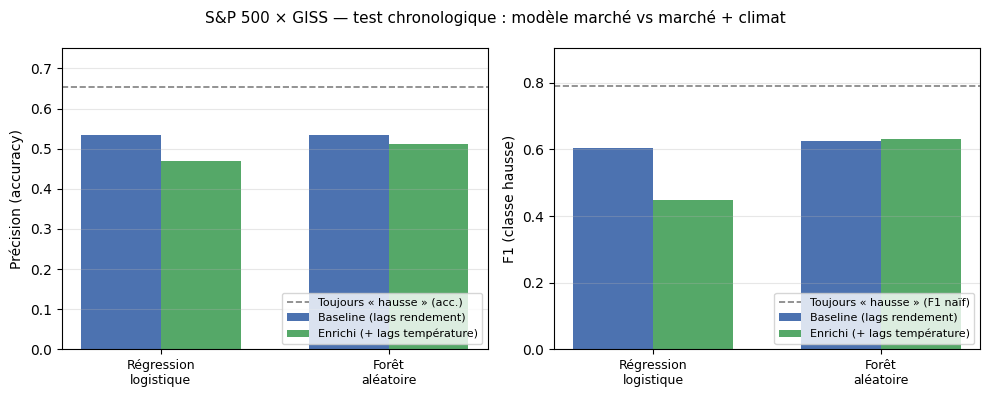

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Même jeu que la cellule d'évaluation (exécuter les cellules sklearn + train au moins une fois).
try:
    _ = X_te_m.shape
except NameError:
    try:
        df_ml = df_merged.copy()
    except NameError:
        df_ml = pd.read_csv(OUT_PATH, parse_dates=["Date"])
    d, y, market_cols, all_cols = load_features(df_ml)
    dates = d["Date"]
    X_mkt = d[market_cols]
    X_all = d[all_cols]
    X_tr_m, X_te_m, y_tr, y_te, split = chronological_split(X_mkt, y)
    X_tr_c, X_te_c, _, _, _ = chronological_split(X_all, y)


def _test_scores(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    if hasattr(model, "predict_proba"):
        proba1 = model.predict_proba(X_test)[:, 1]
        y_pred = (proba1 >= 0.5).astype(int)
    else:
        y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    return acc, f1


model_specs = [
    ("Régression logistique", make_lr),
    ("Forêt aléatoire", make_rf),
]
acc_base, acc_enr, f1_base, f1_enr = [], [], [], []
for _label, factory in model_specs:
    ab, fb = _test_scores(factory(), X_tr_m, X_te_m, y_tr, y_te)
    ae, fe = _test_scores(factory(), X_tr_c, X_te_c, y_tr, y_te)
    acc_base.append(ab)
    acc_enr.append(ae)
    f1_base.append(fb)
    f1_enr.append(fe)

x = np.arange(len(model_specs))
width = 0.35
p_up_test = float(y_te.mean())
# Référence « toujours prédire hausse » : accuracy = part des mois haussiers ; F1 avec précision = p_up_test, rappel = 1.
acc_naive_up = p_up_test
f1_naive_up = (2 * p_up_test / (1 + p_up_test)) if p_up_test > 0 else 0.0

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
configs = [
    (acc_base, acc_enr, "Précision (accuracy)", acc_naive_up, "Toujours « hausse » (acc.)"),
    (f1_base, f1_enr, "F1 (classe hausse)", f1_naive_up, "Toujours « hausse » (F1 naïf)"),
]
for ax, (base, enr, title, ref_line, ref_label) in zip(axes, configs):
    ax.bar(x - width / 2, base, width, label="Baseline (lags rendement)", color="#4C72B0")
    ax.bar(x + width / 2, enr, width, label="Enrichi (+ lags température)", color="#55A868")
    ax.axhline(ref_line, color="gray", linestyle="--", linewidth=1.2, label=ref_label)
    ax.set_xticks(x)
    ax.set_xticklabels([m[0].replace(" ", "\n") for m in model_specs], fontsize=9)
    ax.set_ylabel(title)
    top = max(ref_line, *base, *enr)
    ax.set_ylim(0, min(1.05, top * 1.12 + 0.02))
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(
    "S&P 500 × GISS — test chronologique : modèle marché vs marché + climat",
    fontsize=11,
)
fig.tight_layout()
plt.show()